
# Imaging Demo

How to create visibility from pixel data and make images.

The example uses ``stixpy`` to obtain STIX pixel data and convert these into visibilities and ``xrayvisim``
to make the images.

Imports


In [1]:
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger('stixpy').setLevel(logging.WARNING)
logger = logging.getLogger('stixpy')
logger.setLevel(logging.WARNING)
# Remove existing handlers (optional but effective)
logger.handlers.clear()
# Add a simple handler if you still want warnings/errors printed
handler = logging.StreamHandler()
handler.setLevel(logging.WARNING)
logger.addHandler(handler)
logging.getLogger('stixpy').disabled = True

import requests
import urllib.request
from bs4 import BeautifulSoup
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import ConnectionPatch
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.visualization import ImageNormalize, SqrtStretch, LogStretch
import sunpy
from sunpy.net import Fido, attrs as a
from sunpy.coordinates import frames, HeliographicStonyhurst, Helioprojective
from sunpy.map import Map, make_fitswcs_header
from sunpy.time import TimeRange
from xrayvision.clean import vis_clean
from xrayvision.imaging import vis_to_image, vis_to_map
# from xrayvision.mem import mem, resistant_mean
import stixpy                                  # This registers the a.stix attrs
from stixpy.calibration.visibility import calibrate_visibility, create_meta_pixels, create_visibility
from stixpy.coordinates.frames import STIXImaging
from stixpy.coordinates.transforms import get_hpc_info
# from stixpy.imaging.em import em
from stixpy.map.stix import STIXMap
from stixpy.product import Product

Read science file as Product



In [4]:
def find_links(url='http://www.python.org'):
    """
    Get all the links in a webpage.
    Source: https://stackoverflow.com/questions/20150184/make-a-list-of-all-the-files-on-a-website
    """
    soup = BeautifulSoup(requests.get(url).text)
    hrefs = []
    for a in soup.find_all('a'):
        hrefs.append(a['href'])
    return hrefs


def extract_timerange(filename):
    # isolate the time part
    time_part = filename.split('_')[3]  # '20260118T000340-20260118T000644'
    start_str, end_str = time_part.split('-')
    t_start = datetime.strptime(start_str, '%Y%m%dT%H%M%S')
    t_end   = datetime.strptime(end_str,   '%Y%m%dT%H%M%S')
    return t_start, t_end


def is_overlap(file_start, file_end, query_start, query_end):
    # overlap condition
    return not (file_end < query_start or file_start > query_end)

In [27]:
start_date           = '2025-10-06T08:45:00'
YEAR, MONTH, DAY     = start_date.split('T')[0].split('-')
HOUR, MINUTE, SECOND = start_date.split('T')[1].split(':')
dt_hr  = 1
dt_min = -30
print(YEAR, MONTH, DAY, HOUR, MINUTE, SECOND)

# show the links of the CPD SCI files
sci_url = f'https://pub099.cs.technik.fhnw.ch/fits/L1/{YEAR}/{MONTH}/{DAY}/SCI/'
list_sci_links = find_links(url=sci_url)

# show what you've found
for i, link in enumerate(list_sci_links):
    print(i, link)

2025 10 06 08 45 00
0 ?C=N;O=D
1 ?C=M;O=A
2 ?C=S;O=A
3 ?C=D;O=A
4 /fits/L1/2025/10/06/
5 solo_L1_stix-sci-aspect-burst_20251006T020000-20251006T075958_V02_2510031479.fits
6 solo_L1_stix-sci-aspect-burst_20251006T075959-20251006T135958_V02_2510039907.fits
7 solo_L1_stix-sci-aspect-burst_20251006T135959-20251006T195958_V02_2510033243.fits
8 solo_L1_stix-sci-aspect-burst_20251006T175259-20251006T180258_V02_2510069925.fits
9 solo_L1_stix-sci-aspect-burst_20251006T195959-20251006T230003_V02_2510039417.fits
10 solo_L1_stix-sci-aspect-burst_20251006T225959-20251007T045958_V02_2510060820.fits
11 solo_L1_stix-sci-xray-cpd_20251006T000001-20251006T060014_V02_2510067007-51035.fits
12 solo_L1_stix-sci-xray-cpd_20251006T060014-20251006T120002_V02_2510069289-51036.fits
13 solo_L1_stix-sci-xray-cpd_20251006T064534-20251006T065203_V02_2510060607-50683.fits
14 solo_L1_stix-sci-xray-cpd_20251006T065802-20251006T074602_V02_2510067275-50230.fits
15 solo_L1_stix-sci-xray-cpd_20251006T083231-20251006T090411

In [34]:
sci_query_start = datetime(2025, 10, 6, 8, 45, 0)
sci_query_end   = datetime(2025, 10, 6, 9, 15, 0)

# sci_query_start = datetime(int(YEAR), int(MONTH), int(DAY), int(HOUR), int(MINUTE), int(SECOND))
# sci_query_end   = datetime(int(YEAR), int(MONTH), int(DAY), int(HOUR)+dt_hr, int(MINUTE)+dt_min, int(SECOND))
print(sci_query_start, sci_query_end, sep='\n')

2025-10-06 08:45:00
2025-10-06 09:15:00


In [35]:
valid_sci_files = []

for link in list_sci_links:
    if not link.endswith('.fits'):
        continue
    
    f_start, f_end = extract_timerange(link)

    if 'cpd' in link:    
        if is_overlap(f_start, f_end, sci_query_start, sci_query_end):
            valid_sci_files.append(link)

print(*valid_sci_files, sep='\n')

solo_L1_stix-sci-xray-cpd_20251006T060014-20251006T120002_V02_2510069289-51036.fits
solo_L1_stix-sci-xray-cpd_20251006T083231-20251006T090411_V02_2510060001-50684.fits


In [36]:
sci_file_idx = 1
cpd_sci =  Product(f'{sci_url}/{valid_sci_files[sci_file_idx]}')
cpd_sci

CompressedPixelData   <sunpy.time.timerange.TimeRange object at 0x7e0546539510>
    Start: 2025-10-06 08:32:31
    End:   2025-10-06 09:04:11
    Center:2025-10-06 08:48:21
    Duration:0.02198726851851851 days or
           0.5276944444444442 hours or
           31.661666666666655 minutes or
           1899.6999999999994 seconds
    DetectorMasks
    [0...185]: [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31]

    PixelMasks
    [0...185]: [['1' '1' '1' '1' '1' '1' '1' '1' '0' '0' '0' '0']]

    EnergyEdgeMasks
    [0]: [_,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,_,_,_,_,_,_,_,_,_,_,_,_,_,_]

Read background file as Product



In [37]:
bkg_query_start = datetime(2025, 10, 6, 8, 0, 0)
bkg_query_end   = datetime(2025, 10, 6, 8, 30, 0)

valid_bkg_files = []

for link in list_sci_links:
    if not link.endswith('.fits'):
        continue
    
    f_start, f_end = extract_timerange(link)

    if 'cpd' in link:    
        if is_overlap(f_start, f_end, bkg_query_start, bkg_query_end):
            valid_bkg_files.append(link)

print(*valid_bkg_files, sep='\n')

solo_L1_stix-sci-xray-cpd_20251006T060014-20251006T120002_V02_2510069289-51036.fits


In [41]:
bkg_file_idx = 0
cpd_bkg =  Product(f'{sci_url}/{valid_bkg_files[bkg_file_idx]}')
cpd_bkg

CompressedPixelData   <sunpy.time.timerange.TimeRange object at 0x7e04c3d22290>
    Start: 2025-10-06 06:00:14
    End:   2025-10-06 12:00:02
    Center:2025-10-06 09:00:08
    Duration:0.24986111111111114 days or
           5.996666666666668 hours or
           359.80000000000007 minutes or
           21588.000000000004 seconds
    DetectorMasks
    [0...348]: [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31]

    PixelMasks
    [0...348]: [['1' '1' '1' '1' '1' '1' '1' '1' '0' '0' '0' '0']]

    EnergyEdgeMasks
    [0]: [_,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,_,_,_,_,_,_,_,_,_,_,_,_,_,_]

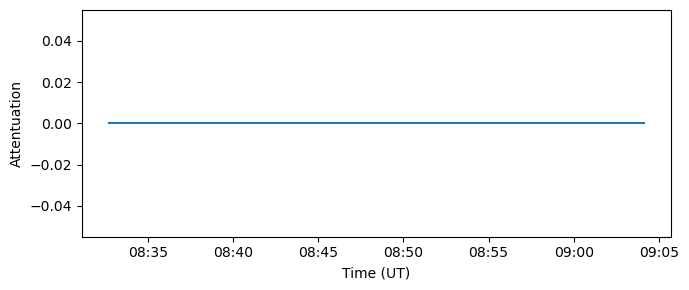

In [42]:
fig = plt.figure(figsize=[7,3])
ax  = fig.add_subplot(111)
ax.plot(cpd_sci.times.datetime, cpd_sci.data['rcr'])
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Attentuation')
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.tight_layout()
plt.show()

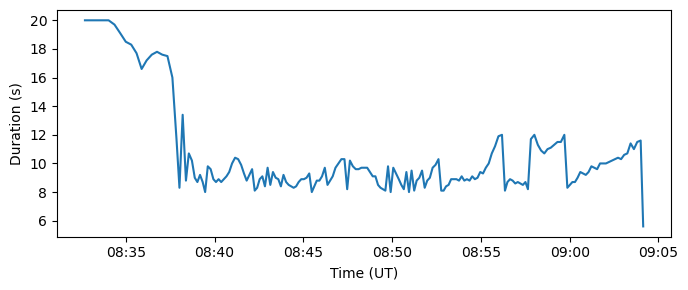

In [43]:
fig = plt.figure(figsize=[7,3])
ax  = fig.add_subplot(111)
ax.plot(cpd_sci.times.datetime, cpd_sci.duration.to_value('s'))
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Duration (s)')
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig.tight_layout()
plt.show()

Set time and energy ranges which will be considered for the science and the background file



In [71]:
# energy_dict = {
#     '4 - 9 keV':   [ 4,  9],
#     '6 - 15 keV':  [ 6, 15],
#     '35 - 76 keV': [36, 76],
#     '15 - 28 keV': [15, 28]
# }

# for i, item in enumerate(energy_dict):
#     print(i, ':', item, '\t-->', energy_dict[item])

In [70]:
# time_range_sci = [sci_query_start, sci_query_end]
# time_range_bkg = [bkg_query_start, bkg_query_end] # Set this range larger than the actual observation time

# xray_band = '6 - 15 keV'
# energy_range = energy_dict[xray_band]*u.keV

Create the meta pixel, A, B, C, D for the science and the background data



In [69]:
# meta_pixels_sci = create_meta_pixels(
#     cpd_sci, time_range=time_range_sci, energy_range=energy_range, flare_location=[0, 0] * u.arcsec, no_shadowing=True
# )

# meta_pixels_bkg = create_meta_pixels(
#     cpd_bkg, time_range=time_range_bkg, energy_range=energy_range, flare_location=[0, 0] * u.arcsec, no_shadowing=True
# )

Perform background subtraction



In [68]:
# meta_pixels_bkg_subtracted = {
#     **meta_pixels_sci,
#     "abcd_rate_kev_cm": meta_pixels_sci["abcd_rate_kev_cm"] - meta_pixels_bkg["abcd_rate_kev_cm"],
#     "abcd_rate_error_kev_cm": np.sqrt(
#         meta_pixels_sci["abcd_rate_error_kev_cm"] ** 2 + meta_pixels_bkg["abcd_rate_error_kev_cm"] ** 2
#     ),
# }

Create visibilities from the meta pixels



In [67]:
# vis = create_visibility(meta_pixels_bkg_subtracted)

Obtain the necessary ephemeris data create HPC 0,0 coordinate

In [66]:
# res = Fido.search(
#     a.Time('2026-01-18T16:00', '2026-01-18T18:00'),
#     a.Instrument.stix,
#     a.stix.DataType.asp,
#     a.stix.DataProduct.asp_ephemeris,
# )
# print(res)

In [65]:
# vis_tr = TimeRange(vis.meta["time_range"])
# roll, solo_xyz, pointing = get_hpc_info(vis_tr.start, vis_tr.end)
# solo = HeliographicStonyhurst(*solo_xyz, obstime=vis_tr.center, representation_type="cartesian")
# center_hpc = SkyCoord(0 * u.deg, 0 * u.deg, frame=Helioprojective(obstime=vis_tr.center, observer=solo))

In [64]:
# vis

In [63]:
# vis.meta["time_range"]

Calibrate the visibilities

If not given will default to sun center flare location



In [62]:
# cal_vis = calibrate_visibility(vis, flare_location=center_hpc)

Selected detectors 10 to 7



In [61]:
# # order by sub-collimator e.g. 10a, 10b, 10c, 9a, 9b, 9c ....
# isc_10_7 = [3, 20, 22, 16, 14, 32, 21, 26, 4, 24, 8, 28]
# idx = np.argwhere(np.isin(cal_vis.meta["isc"], isc_10_7)).ravel()

Slice the visibilities to detectors 10 - 7



In [60]:
# vis10_7 = cal_vis[idx]

Set up image parameters



In [59]:
# imsize = [512, 512] * u.pixel  # number of pixels of the map to reconstruct
# pixel = [10, 10] * u.arcsec / u.pixel  # pixel size in arcsec

Make a full disk back projection (inverse transform) map



In [58]:
# bp_image = vis_to_image(vis10_7, imsize, pixel_size=pixel)

Obtain the necessary ephemeris data



In [57]:
# vis_tr = TimeRange(vis.meta["time_range"])
# roll, solo_xyz, pointing = get_hpc_info(vis_tr.start, vis_tr.end)
# solo = HeliographicStonyhurst(*solo_xyz, obstime=vis_tr.center, representation_type="cartesian")
# coord_stix = center_hpc.transform_to(STIXImaging(obstime=vis_tr.start, obstime_end=vis_tr.end, observer=solo))
# header = make_fitswcs_header(
#     bp_image, coord_stix, telescope="STIX", observatory="Solar Orbiter", scale=[10, 10] * u.arcsec / u.pix
# )
# fd_bp_map = Map((bp_image, header))

Convert the coordinates and make a map in Helioprojective and rotate so "North" is "up"
Center of STIX pointing in HPC



In [56]:
# header_hp = make_fitswcs_header(
#     bp_image, center_hpc, scale=[10,10]*u.arcsec / u.pix, rotation_angle=90 * u.deg + roll
# )
# hp_map = Map((bp_image, header_hp))
# hp_map_rotated = hp_map.rotate()

Plot the both maps



In [55]:
# fig = plt.figure(layout="constrained", figsize=[12,6])
# ax = fig.subplot_mosaic(
#     [["stix", "hpc"]], per_subplot_kw={"stix": {"projection": fd_bp_map}, "hpc": {"projection": hp_map_rotated}}
# )
# fd_bp_map.plot(axes=ax["stix"])
# fd_bp_map.draw_limb()
# fd_bp_map.draw_grid()

# hp_map_rotated.plot(axes=ax["hpc"])
# hp_map_rotated.draw_limb()
# hp_map_rotated.draw_grid()

# """
# Estimate the flare location and plot on top of back projection map.
# Note the coordinates are automatically converted from the STIXImaging to Helioprojective.
# """
# max_pixel = np.argwhere(fd_bp_map.data == fd_bp_map.data.max()).ravel() * u.pixel
# # because WCS axes and array are reversed
# max_stix = fd_bp_map.pixel_to_world(max_pixel[1], max_pixel[0])

# ax["stix"].plot_coord(max_stix, marker=".", markersize=50, fillstyle="none", color="r", markeredgewidth=2)
# ax["hpc"].plot_coord(max_stix, marker=".", markersize=50, fillstyle="none", color="r", markeredgewidth=2)
# fig.tight_layout()
# plt.show()

Use estimated flare location to create more accurate visibilities



In [54]:
# meta_pixels_sci = create_meta_pixels(
#     cpd_sci, time_range=time_range_sci, energy_range=energy_range, flare_location=max_stix, no_shadowing=True
# )

# meta_pixels_bkg_subtracted = {
#     **meta_pixels_sci,
#     "abcd_rate_kev_cm": meta_pixels_sci["abcd_rate_kev_cm"] - meta_pixels_bkg["abcd_rate_kev_cm"],
#     "abcd_rate_error_kev_cm": np.sqrt(
#         meta_pixels_sci["abcd_rate_error_kev_cm"] ** 2 + meta_pixels_bkg["abcd_rate_error_kev_cm"] ** 2
#     ),
# }

# vis = create_visibility(meta_pixels_bkg_subtracted)
# cal_vis = calibrate_visibility(vis, flare_location=max_stix)

Selected detectors 10 to 3
order by sub-collimator e.g. 10a, 10b, 10c, 9a, 9b, 9c ....



In [53]:
# isc_10_3 = [3, 20, 22, 16, 14, 32, 21, 26, 4, 24, 8, 28, 15, 27, 31, 6, 30, 2, 25, 5, 23, 7, 29, 1]
# idx = np.argwhere(np.isin(cal_vis.meta["isc"], isc_10_3)).ravel()

Create an ``xrayvsion`` visibility object



In [52]:
# cal_vis.meta['offset'] = max_stix
# vis10_3 = cal_vis[idx]

Set up image parameters



In [51]:
# imsize = [129, 129]*u.pixel        # number of pixels of the map to reconstruct
# pixel = [2, 2]*u.arcsec / u.pixel  # pixel size in arcsec

Create a clean image using the clean algorithm `vis_clean`

In [50]:
# niter = 200  # number of iterations
# gain = 0.1   # gain used in each clean iteration
# beam_width = 20.0 * u.arcsec
# clean_map, model_map, resid_map = vis_clean(
#     vis10_3, imsize, pixel_size=pixel, gain=gain, niter=niter, clean_beam_width=20 * u.arcsec
# )

Create a sunpy map for the clean image in Helioprojective



In [49]:
# header = make_fitswcs_header(
#     clean_map.data,
#     max_stix.transform_to(Helioprojective(obstime=vis_tr.center, observer=solo)),
#     telescope='STIX',
#     observatory='Solar Orbiter',
#     scale=pixel,
#     rotation_angle=90*u.deg + roll,
# )

# clean_map = Map((clean_map.data, header)).rotate()
# # vmax = clean_map.data.max()

In [48]:
# # Plot the Clean method
# fig = plt.figure(figsize=[5,5])
# ax  = fig.add_subplot(111, projection=clean_map)
# clean_map.plot(axes=ax, cmap='RdYlBu_r')

# with sunpy.coordinates.frames.Helioprojective.assume_spherical_screen(clean_map.observer_coordinate):
#     # c0 = clean_map.draw_contours(levels=(70)*u.percent, autoalign=True, fill=True, colors='black', alpha=0.3)
#     c0 = clean_map.draw_contours(levels=(70)*u.percent, axes=ax, autoalign=True, colors='black')

# # find the maxima pixel locations for the clean stix map
# clean_map_maxloc = np.unravel_index(np.nanargmax(clean_map.data), clean_map.data.shape)*u.pixel
# # convert to sky coordinates
# maxcoords = clean_map.pixel_to_world(clean_map_maxloc[1], clean_map_maxloc[0])
# # plot the maxima centroids
# ax.plot_coord(maxcoords, 'wx', fillstyle='none', markersize=5, linewidth=5, color='black')

# ax.grid(False)
# fig.tight_layout()
# plt.show()

In [72]:
# t = clean_map.meta['date-obs']

# dt = datetime.fromisoformat(t)
# dt_new = dt + timedelta(seconds=12)

# print(t, dt_new.isoformat())

In [73]:
# aia_result = Fido.search(a.Time(t, dt_new),
#                          a.Instrument('AIA'),
#                          a.Wavelength(193*u.angstrom),
#                          a.Sample(12*u.second)
#                         )
# aia_files = Fido.fetch(aia_result, site='NSO')

In [74]:
# aia_files

In [75]:
# aia = sunpy.map.Map(aia_files[0])
# # aia.plot_settings['norm'] = ImageNormalize(vmin=50, vmax=3e3, stretch=SqrtStretch())
# # aia.plot_settings['norm'] = ImageNormalize(vmin=-1e2, vmax=1e4, stretch=LogStretch())

# fig = plt.figure(figsize=[7,7])
# ax = fig.add_subplot(projection=aia)
# m = aia.plot(axes=ax, clip_interval=(1, 99.9)*u.percent)
# fig.colorbar(m, ax=ax, pad=0.01, shrink=0.8, label=aia.meta['pixlunit'])
# ax.grid(False)
# fig.tight_layout()
# plt.show()

In [77]:
# fig = plt.figure(figsize=[7,7])
# ax  = fig.add_subplot(111, projection=aia)
# aia.plot(axes=ax, clip_interval=(1, 99.9)*u.percent, cmap='Greys')

# with frames.Helioprojective.assume_spherical_screen(aia.observer_coordinate):
#     clean_map_proj = clean_map.reproject_to(aia.wcs)

# clean_map_proj.draw_contours(axes=ax, levels=np.arange(70, 100, 10)*u.percent, autoalign=True, colors='red')

# ax.grid(False)
# fig.tight_layout()
# plt.show()

In [40]:
# fig = plt.figure(figsize=[7,7])
# ax = fig.add_subplot(111, projection=aia)
# aia.plot(axes=ax, cmap='Greys')

# with frames.Helioprojective.assume_spherical_screen(aia.observer_coordinate):
#     clean_map_proj = clean_map.reproject_to(aia.wcs)
#     clean_map_proj.draw_contours(axes=ax, levels=np.arange(70, 100, 10)*u.percent, autoalign=True, colors='red')

# ax.grid(False)
# fig.tight_layout()
# plt.show()

In [47]:
# top_right   = SkyCoord(-350*u.arcsec, -100*u.arcsec, frame=aia.coordinate_frame)
# bottom_left = SkyCoord(-600*u.arcsec, -300*u.arcsec, frame=aia.coordinate_frame)
# aia_sub = aia.submap(bottom_left, top_right=top_right)

# fig = plt.figure(figsize=[7,7])
# ax = fig.add_subplot(projection=aia_sub)
# aia_sub.plot(axes=ax, clip_interval=(1, 99.9)*u.percent)

# with frames.Helioprojective.assume_spherical_screen(aia_sub.observer_coordinate):
#     clean_map_proj = clean_map.reproject_to(aia_sub.wcs)

# # clean_map_proj.draw_contours(levels=np.arange(70, 100, 10)*u.percent, axes=ax, autoalign=True, colors='red')/
# clean_map_proj.draw_contours(levels=[50,60,70,80,90]*u.percent, axes=ax, autoalign=True, colors='red')

# ax.grid(False)
# fig.tight_layout()
# plt.show()

In [46]:
# #### The first stage is plotting the full-disk AIA 193 Ao
# fig = plt.figure(figsize=[14,7])

# ax1 = fig.add_subplot(121, projection=aia)
# # aia.plot(axes=ax1, cmap='Greys')
# aia.plot(axes=ax1, clip_interval=(1, 99.9)*u.percent)
# aia.draw_grid(axes=ax1, color='black', alpha=0.25, lw=0.5)
# ax1.grid(b=False)

# # draw the rectangle around the region we plan to showcase in the cutout image
# aia.draw_quadrangle(bottom_left, top_right=top_right, edgecolor='black', lw=1)

# #### The second stage is plotting the zoomed-in map
# ax2 = fig.add_subplot(122, projection=aia_sub)
# aia_sub.plot(axes=ax2, clip_interval=(1, 99.9)*u.percent)
# ax2.grid(False)

# with frames.Helioprojective.assume_spherical_screen(aia_sub.observer_coordinate):
#     clean_map_proj = clean_map.reproject_to(aia_sub.wcs)
# clean_map_proj.draw_contours(levels=[50,60,70,80,90]*u.percent, axes=ax2, autoalign=True, colors='red')

# ax2.plot([], [], color='red', lw=2, label=xray_band)
# ax2.legend(loc='upper left')

# # clean up the axis labels and ticks
# lon, lat = ax2.coords[0], ax2.coords[1]
# lon.frame.set_linewidth(1)
# lat.frame.set_linewidth(1)
# lon.set_axislabel('Helioprojective Longitude',)
# lon.set_ticks_position('b')
# lat.set_axislabel('Helioprojective Latitude',)
# lat.set_axislabel_position('r')
# lat.set_ticks_position('r')
# lat.set_ticklabel_position('r')

# # we add two lines that will connect the two images as well as a colorbar
# xpix, ypix = aia.world_to_pixel(top_right)
# con1 = ConnectionPatch(
#     (0,1), (xpix.value, ypix.value), 'axes fraction', 'data', axesA=ax2, axesB=ax1, 
#     arrowstyle='-', color='black', lw=1)

# xpix, ypix = aia.world_to_pixel(SkyCoord(top_right.Tx, bottom_left.Ty, frame=aia.coordinate_frame))
# con2 = ConnectionPatch(
#     (0,0), (xpix.value, ypix.value), 'axes fraction', 'data', axesA=ax2, axesB=ax1, arrowstyle='-', color='black', lw=1)

# ax2.add_artist(con1)
# ax2.add_artist(con2)
# plt.show()

In [ ]:
fig = plt.figure(layout="constrained", figsize=[12,6])
ax = fig.subplot_mosaic(
    [["stix", "hpc"]], per_subplot_kw={"stix": {"projection": fd_bp_map}, "hpc": {"projection": hp_map_rotated}}
)
fd_bp_map.plot(axes=ax["stix"])
fd_bp_map.draw_limb()
fd_bp_map.draw_grid()

hp_map_rotated.plot(axes=ax["hpc"])
hp_map_rotated.draw_limb()
hp_map_rotated.draw_grid()



ax["stix"].plot_coord(max_stix, marker=".", markersize=50, fillstyle="none", color="r", markeredgewidth=2)
ax["hpc"].plot_coord(max_stix, marker=".", markersize=50, fillstyle="none", color="r", markeredgewidth=2)
fig.tight_layout()
plt.show()

In [45]:
energy_dict = {
    '4 - 9 keV':   [ 4,  9],
    '6 - 15 keV':  [ 6, 15],
    '15 - 28 keV': [15, 28],
    '35 - 76 keV': [36, 76]
}

for i, item in enumerate(energy_dict):
    print(i, ':', item, '\t-->', energy_dict[item])

0 : 4 - 9 keV 	--> [4, 9]
1 : 6 - 15 keV 	--> [6, 15]
2 : 15 - 28 keV 	--> [15, 28]
3 : 35 - 76 keV 	--> [36, 76]


In [84]:
time_range_sci = [sci_query_start, sci_query_end]
time_range_bkg = [bkg_query_start, bkg_query_end] # Set this range larger than the actual observation time

clean_stix_maps = {}

# Define the energy range for STIX (in keV)
for item in energy_dict:
    energy_range = energy_dict[item]*u.keV

    try:
        # Create the meta pixel, A, B, C, D for the science and the background data
        meta_pixels_sci = create_meta_pixels(
            cpd_sci, time_range=time_range_sci, energy_range=energy_range, flare_location=[0,0]*u.arcsec, no_shadowing=True
        )
        meta_pixels_bkg = create_meta_pixels(
            cpd_bkg, time_range=time_range_bkg, energy_range=energy_range, flare_location=[0,0]*u.arcsec, no_shadowing=True
        )
        
        # Perform background subtraction
        meta_pixels_bkg_subtracted = {
            **meta_pixels_sci,
            'abcd_rate_kev_cm': meta_pixels_sci['abcd_rate_kev_cm'] - meta_pixels_bkg['abcd_rate_kev_cm'],
            'abcd_rate_error_kev_cm': np.sqrt(
                meta_pixels_sci['abcd_rate_error_kev_cm']**2 + meta_pixels_bkg['abcd_rate_error_kev_cm']**2
            )
        }
        
        # Create visibilities from the meta pixels
        vis = create_visibility(meta_pixels_bkg_subtracted)
        cal_vis = calibrate_visibility(vis, flare_location=center_hpc)
        
        # Create the time range for the visibility data and get the HPC coords of the observer (SolO) and the centre of the Sun in Helioprojective coords
        vis_tr = TimeRange(vis.meta['time_range'])
        roll, solo_xyz, pointing = get_hpc_info(vis_tr.start, vis_tr.end)
        solo = HeliographicStonyhurst(*solo_xyz, obstime=vis_tr.center, representation_type='cartesian')
        center_hpc = SkyCoord(0*u.deg, 0*u.deg, frame=Helioprojective(obstime=vis_tr.center, observer=solo))
        
        # Calibrate the visibilities: If not given will default to sun center flare location
        # order by sub-collimator e.g. 10a, 10b, 10c, 9a, 9b, 9c ....
        isc_10_7 = [3, 20, 22, 16, 14, 32, 21, 26, 4, 24, 8, 28]
        idx = np.argwhere(np.isin(cal_vis.meta['isc'], isc_10_7)).ravel()
        
        # Slice the visibilities to detectors 10 - 7
        vis10_7 = cal_vis[idx]
        
        # Set up image parameters
        imsize = [512, 512]*u.pixel           # number of pixels of the map to reconstruct
        pixel  = [10, 10]*u.arcsec / u.pixel  # pixel size in arcsec
        
        # Make a full disk back projection (inverse transform) map
        bp_image = vis_to_image(vis10_7, imsize, pixel_size=pixel)
        
        # Obtain the necessary ephemeris data
        vis_tr = TimeRange(vis.meta['time_range'])
        roll, solo_xyz, pointing = get_hpc_info(vis_tr.start, vis_tr.end)
        solo = HeliographicStonyhurst(*solo_xyz, obstime=vis_tr.center, representation_type='cartesian')
        coord_stix = center_hpc.transform_to(STIXImaging(obstime=vis_tr.start, obstime_end=vis_tr.end, observer=solo))
        header = make_fitswcs_header(
            bp_image, coord_stix, telescope='STIX', observatory='Solar Orbiter', scale=[10,10]*u.arcsec / u.pix
        )
        fd_bp_map = Map((bp_image, header))
        
        # Convert the coordinates and make a map in Helioprojective and rotate so "North" is "up" Center of STIX pointing in HPC
        header_hp = make_fitswcs_header(
            bp_image, center_hpc, scale=[10,10]*u.arcsec / u.pix, rotation_angle=90*u.deg + roll
        )
        hp_map = Map((bp_image, header_hp))
        hp_map_rotated = hp_map.rotate()
        
        # Use estimated flare location to create more accurate visibilities
        """
        Estimate the flare location and plot on top of back projection map.
        Note the coordinates are automatically converted from the STIXImaging to Helioprojective.
        """
        max_pixel = np.argwhere(fd_bp_map.data == fd_bp_map.data.max()).ravel()*u.pixel
        max_stix = fd_bp_map.pixel_to_world(max_pixel[1], max_pixel[0]) # because WCS axes and array are reversed
        
        meta_pixels_sci = create_meta_pixels(
            cpd_sci, time_range=time_range_sci, energy_range=energy_range, flare_location=max_stix, no_shadowing=True
        )
        
        meta_pixels_bkg_subtracted = {
            **meta_pixels_sci,
            'abcd_rate_kev_cm': meta_pixels_sci['abcd_rate_kev_cm'] - meta_pixels_bkg['abcd_rate_kev_cm'],
            'abcd_rate_error_kev_cm': np.sqrt(
                meta_pixels_sci['abcd_rate_error_kev_cm']**2 + meta_pixels_bkg['abcd_rate_error_kev_cm']**2
            )
        }
        vis = create_visibility(meta_pixels_bkg_subtracted)
        cal_vis = calibrate_visibility(vis, flare_location=max_stix)
        
        # Selected detectors 10 to 3 order by sub-collimator e.g. 10a, 10b, 10c, 9a, 9b, 9c, ...
        isc_10_3 = [3, 20, 22, 16, 14, 32, 21, 26, 4, 24, 8, 28, 15, 27, 31, 6, 30, 2, 25, 5, 23, 7, 29, 1]
        idx = np.argwhere(np.isin(cal_vis.meta['isc'], isc_10_3)).ravel()
        
        # Create an xrayvsion visibility object
        cal_vis.meta['offset'] = max_stix
        vis10_3 = cal_vis[idx]
        
        # Set up image parameters
        imsize = [129, 129]*u.pixel        # number of pixels of the map to reconstruct
        pixel = [2, 2]*u.arcsec / u.pixel  # pixel size in arcsec
        
        # Create a clean image using the clean algorithm vis_clean
        niter = 200  # number of iterations
        gain = 0.1   # gain used in each clean iteration
        beam_width = 20.0 * u.arcsec
        clean_map, model_map, resid_map = vis_clean(
            vis10_3, imsize, pixel_size=pixel, gain=gain, niter=niter, clean_beam_width=20 * u.arcsec
        )
        
        # Create a sunpy map for the clean image in Helioprojective
        header = make_fitswcs_header(
            clean_map.data,
            max_stix.transform_to(Helioprojective(obstime=vis_tr.center, observer=solo)),
            telescope='STIX',
            observatory='Solar Orbiter',
            scale=pixel,
            rotation_angle=90*u.deg + roll,
        )
        clean_map = Map((clean_map.data, header)).rotate()
        clean_stix_maps[item] = clean_map
        
        print(f'STIX cannel {item} keV is cleaned and ready')
    except:
        print(f'STIX energy band {item} is unavailable!')

2026-04-20T20:55:09Z INFO xrayvision.clean 124: Iter: 0, strength: 2.4754525903528894, location: (np.int64(63), np.int64(58))
2026-04-20 20:55:09 - xrayvision.clean - INFO: Iter: 0, strength: 2.4754525903528894, location: (np.int64(63), np.int64(58))
2026-04-20T20:55:09Z INFO xrayvision.clean 145: Largest residual negative
2026-04-20 20:55:09 - xrayvision.clean - INFO: Largest residual negative


STIX cannel 4 - 9 keV keV is cleaned and ready


2026-04-20T20:55:14Z INFO xrayvision.clean 124: Iter: 0, strength: 1.2269311515209635, location: (np.int64(65), np.int64(64))
2026-04-20 20:55:14 - xrayvision.clean - INFO: Iter: 0, strength: 1.2269311515209635, location: (np.int64(65), np.int64(64))
2026-04-20T20:55:14Z INFO xrayvision.clean 145: Largest residual negative
2026-04-20 20:55:14 - xrayvision.clean - INFO: Largest residual negative


STIX cannel 6 - 15 keV keV is cleaned and ready


2026-04-20T20:55:19Z INFO xrayvision.clean 124: Iter: 0, strength: 0.016045876890741207, location: (np.int64(66), np.int64(67))
2026-04-20 20:55:19 - xrayvision.clean - INFO: Iter: 0, strength: 0.016045876890741207, location: (np.int64(66), np.int64(67))
2026-04-20T20:55:19Z INFO xrayvision.clean 145: Largest residual negative
2026-04-20 20:55:19 - xrayvision.clean - INFO: Largest residual negative


STIX cannel 15 - 28 keV keV is cleaned and ready
STIX energy band 35 - 76 keV is unavailable!


In [122]:
item = list(energy_dict)[0]
t  = clean_stix_maps[item].meta['date-obs']
dt = datetime.fromisoformat(t)
dt_new = dt + timedelta(seconds=12)
print(t, dt_new.isoformat())

aia_result = Fido.search(a.Time(t, dt_new),
                         a.Instrument('AIA'),
                         a.Wavelength(193*u.angstrom),
                         a.Sample(12*u.second)
                        )
aia_files = Fido.fetch(aia_result, site='NSO')
print(*aia_files, sep='\n')

2025-10-06T08:54:34.150 2025-10-06T08:54:46.150000


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

aia.lev1.193A_2025_10_06T08_54_40.84Z.image_lev1.fits:   0%|          | 0.00/11.9M [00:00<?, ?B/s]

/net/maedoc.ap.dias.ie/maedoc/home_cr/mnedal/sunpy/data/aia.lev1.193A_2025_10_06T08_54_40.84Z.image_lev1.fits


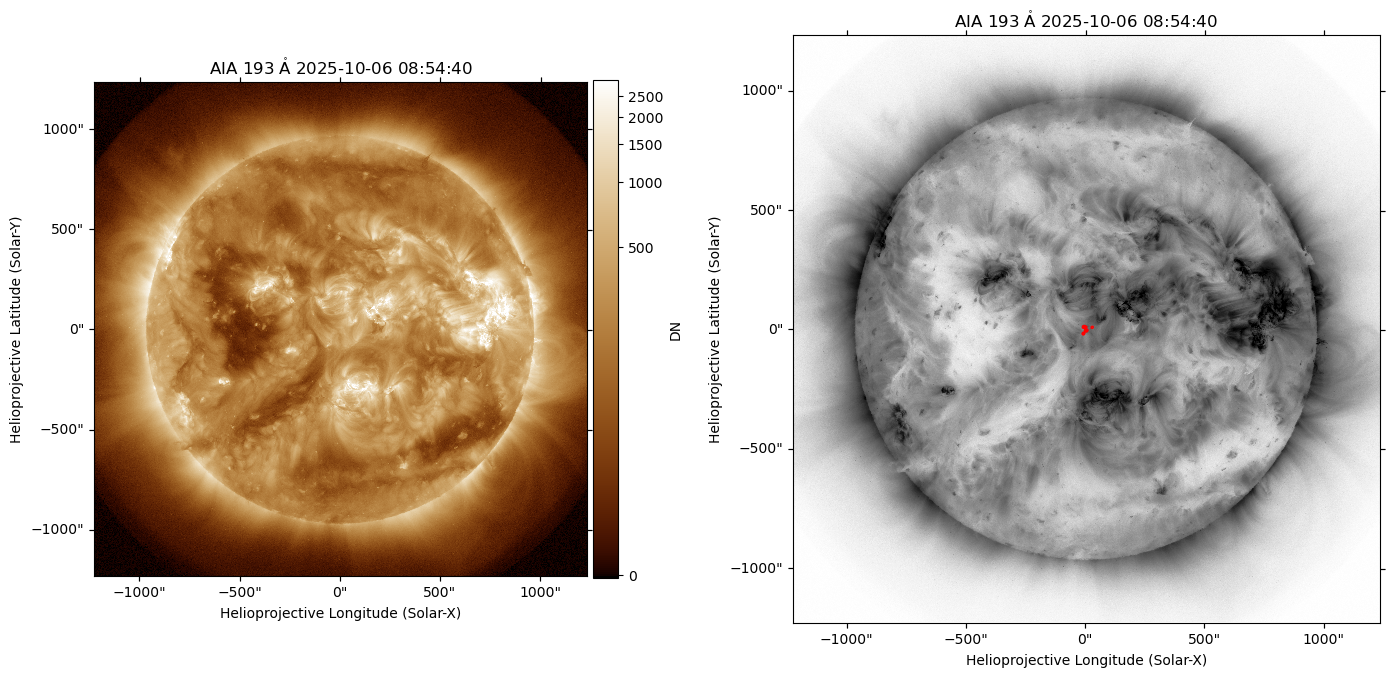

In [128]:
aia_file_idx = 0
aia = sunpy.map.Map(aia_files[aia_file_idx])

fig = plt.figure(figsize=[14,7])

ax = fig.add_subplot(121, projection=aia)
m = aia.plot(axes=ax, clip_interval=(1, 99.9)*u.percent)
fig.colorbar(m, ax=ax, pad=0.01, shrink=0.8, label=aia.meta['pixlunit'])
ax.grid(False)

ax = fig.add_subplot(122, projection=aia)
aia.plot(axes=ax, clip_interval=(1, 99.9)*u.percent, cmap='Greys')

try:
    with frames.Helioprojective.assume_spherical_screen(aia.observer_coordinate):
        clean_map_proj = clean_map.reproject_to(aia.wcs)
except:
    from reproject import reproject_interp
    from sunpy.map.mapbase import GenericMap
    
    with frames.Helioprojective.assume_spherical_screen(aia.observer_coordinate):
        # Bypass STIXMap.wcs and GenericMap.wcs entirely — both call wcs.set()
        # internally and fail. Build a WCS straight from the raw FITS header
        # before stixpy's property modifies the projection parameters.
        stix_wcs = WCS(clean_map.fits_header)
        reprojected_data, _ = reproject_interp(
            (clean_map.data, stix_wcs),
            aia.wcs,
            shape_out=aia.data.shape,
        )
    clean_map_proj = sunpy.map.Map(reprojected_data, aia.wcs)

clean_map_proj.draw_contours(axes=ax, levels=np.arange(70, 100, 10)*u.percent, autoalign=True, colors='red')
ax.grid(False)

fig.tight_layout()
plt.show()

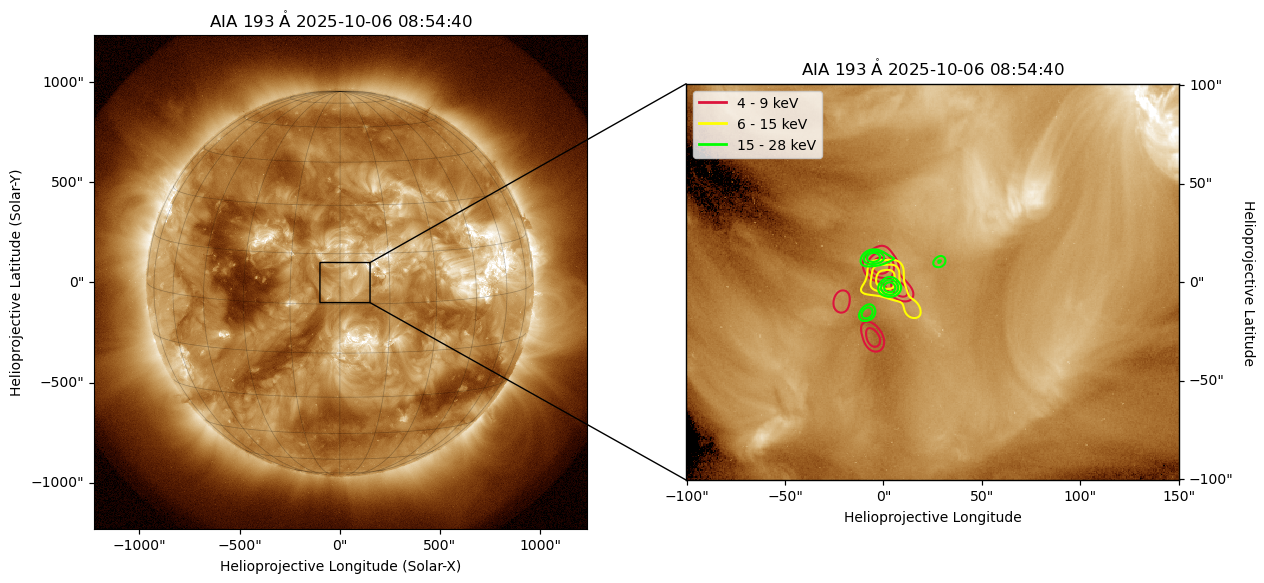

In [132]:
top_right   = SkyCoord(150*u.arcsec, 100*u.arcsec, frame=aia.coordinate_frame)
bottom_left = SkyCoord(-100*u.arcsec, -100*u.arcsec, frame=aia.coordinate_frame)
aia_sub = aia.submap(bottom_left, top_right=top_right)

#### The first stage is plotting the full-disk AIA 193 Ao
fig = plt.figure(figsize=[14,7])

ax1 = fig.add_subplot(121, projection=aia)
# aia.plot(axes=ax1, cmap='Greys')
aia.plot(axes=ax1, clip_interval=(1, 99.9)*u.percent)
aia.draw_grid(axes=ax1, color='black', alpha=0.25, lw=0.5)
ax1.grid(b=False)

# draw the rectangle around the region we plan to showcase in the cutout image
aia.draw_quadrangle(bottom_left, top_right=top_right, edgecolor='black', lw=1)

#### The second stage is plotting the zoomed-in map
ax2 = fig.add_subplot(122, projection=aia_sub)
aia_sub.plot(axes=ax2, clip_interval=(1, 99.9)*u.percent)
ax2.grid(False)

colors = ['crimson', 'yellow', 'lime', 'dodgerblue']
for stix_map, color in zip(clean_stix_maps, colors):
    clean_map = clean_stix_maps[stix_map]
    with frames.Helioprojective.assume_spherical_screen(aia_sub.observer_coordinate):
        # Bypass STIXMap.wcs and GenericMap.wcs entirely — both call wcs.set()
        # internally and fail. Build a WCS straight from the raw FITS header
        # before stixpy's property modifies the projection parameters.
        stix_wcs = WCS(clean_map.fits_header)
        reprojected_data, _ = reproject_interp(
            (clean_map.data, stix_wcs),
            aia_sub.wcs,
            shape_out=aia_sub.data.shape,
        )
    clean_map_proj = sunpy.map.Map(reprojected_data, aia_sub.wcs)
    clean_map_proj.draw_contours(levels=[70,80,90]*u.percent, axes=ax2, autoalign=True, colors=color)
    ax2.plot([], [], color=color, lw=2, label=stix_map)

ax2.legend(loc='upper left')

# clean up the axis labels and ticks
lon, lat = ax2.coords[0], ax2.coords[1]
lon.frame.set_linewidth(1)
lat.frame.set_linewidth(1)
lon.set_axislabel('Helioprojective Longitude',)
lon.set_ticks_position('b')
lat.set_axislabel('Helioprojective Latitude',)
lat.set_axislabel_position('r')
lat.set_ticks_position('r')
lat.set_ticklabel_position('r')

# we add two lines that will connect the two images as well as a colorbar
xpix, ypix = aia.world_to_pixel(top_right)
con1 = ConnectionPatch(
    (0,1), (xpix.value, ypix.value), 'axes fraction', 'data', axesA=ax2, axesB=ax1, 
    arrowstyle='-', color='black', lw=1)

xpix, ypix = aia.world_to_pixel(SkyCoord(top_right.Tx, bottom_left.Ty, frame=aia.coordinate_frame))
con2 = ConnectionPatch(
    (0,0), (xpix.value, ypix.value), 'axes fraction', 'data', axesA=ax2, axesB=ax1, arrowstyle='-', color='black', lw=1)

ax2.add_artist(con1)
ax2.add_artist(con2)
plt.show()